In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Importing Libraries

In [19]:
# Importing libraries 

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
 
import cv2
from PIL import Image
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
 
warnings.filterwarnings('ignore')



# Model constants / configs

In [26]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# checkpoint ko path haru

BASE_DIR   = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
TRAIN_DIR  = BASE_DIR / "Training"
TEST_DIR   = BASE_DIR / "Testing"
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Configs

IMG_SIZE    = 224          # Input image size (224x224)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 3e-1
VAL_SPLIT   = 0.2         # 20% of training data → validation

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

print("="*60)
print("  BRAIN TUMOR MRI - CNN From Scratch")
print("="*60)
print(f"  Image Size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size  : {BATCH_SIZE}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Classes     : {CLASS_NAMES}")
print("="*60)


  BRAIN TUMOR MRI - CNN From Scratch
  Image Size  : 224x224
  Batch Size  : 32
  Epochs      : 50
  Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']


### Output Explanation
In this output, I am confirming that all core experiment settings are initialized correctly. I can see the image size, batch size, epoch count, and class names printed clearly, which helps me verify that the whole pipeline is configured exactly as intended before training starts.

This step is important for reproducibility because if any one of these values is wrong, all later results become hard to trust. By checking this early, I make sure my experiments remain consistent and comparable across runs.

# EDA 


In [21]:
print("\n[EDA] Analyzing dataset structure...")

def count_images(directory: Path) -> dict:
    """Count images per class in a directory."""
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = directory / cls
        if cls_path.exists():
            counts[cls] = len(list(cls_path.glob("*.jpg")) +
                              list(cls_path.glob("*.jpeg")) +
                              list(cls_path.glob("*.png")))
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)
total_train  = sum(train_counts.values())
total_test   = sum(test_counts.values())

print(f"\n  Training samples : {total_train}")
print(f"  Testing  samples : {total_test}")
print(f"  Total            : {total_train + total_test}")
print("\n  Per-class breakdown:")
print(f"  {'Class':<15} {'Train':>8} {'Test':>8} {'Total':>8}")
print("  " + "-"*42)
for cls in CLASS_NAMES:
    print(f"  {cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8} "
          f"{train_counts[cls]+test_counts[cls]:>8}")


[EDA] Analyzing dataset structure...

  Training samples : 5600
  Testing  samples : 1600
  Total            : 7200

  Per-class breakdown:
  Class              Train     Test    Total
  ------------------------------------------
  glioma              1400      400     1800
  meningioma          1400      400     1800
  notumor             1400      400     1800
  pituitary           1400      400     1800


### Output Explanation
Here, I am reading the dataset summary and per-class counts for training and testing folders. This output gives me a quick sanity check that all classes are present and that the data has been loaded from the expected path structure.

I use this table to assess class balance before modeling. If one class has significantly fewer examples, I know in advance that recall for that class may suffer, and I can plan mitigation steps like stronger augmentation, class weighting, or targeted tuning later.

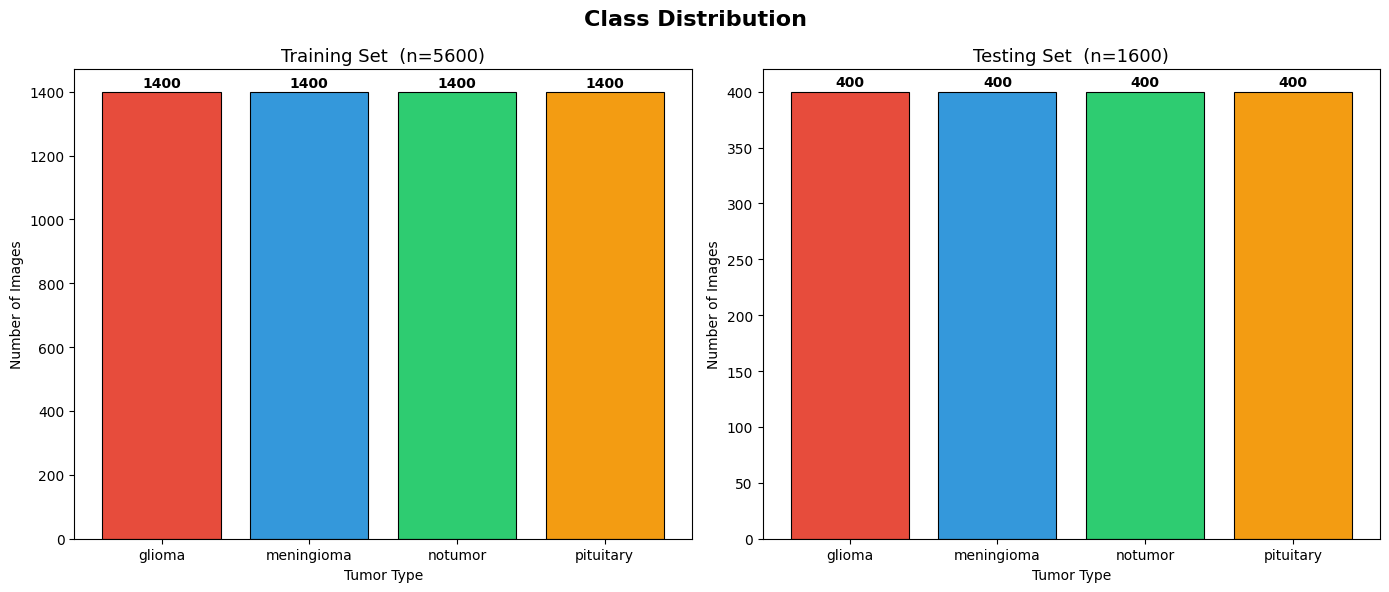

  [✓] Saved: 01_class_distribution.png


In [ ]:
#  2.1 Class Distribution Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Class Distribution", fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Training
axes[0].bar(CLASS_NAMES, train_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title(f"Training Set  (n={total_train})", fontsize=13)
axes[0].set_xlabel("Tumor Type")
axes[0].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(train_counts.items()):
    axes[0].text(i, cnt + 15, str(cnt), ha='center', fontweight='bold')

# Testing
axes[1].bar(CLASS_NAMES, test_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title(f"Testing Set  (n={total_test})", fontsize=13)
axes[1].set_xlabel("Tumor Type")
axes[1].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(test_counts.items()):
    axes[1].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 01_class_distribution.png")

### Output Explanation
This visualization compares class distributions across train and test splits. I use it to visually confirm that each tumor category has meaningful representation and to quickly spot any skew.

The bars and count labels make it easy to evaluate whether the split is reasonable. If the imbalance looks strong, I treat this as an early warning that overall accuracy alone could be misleading, and I should pay extra attention to class-wise metrics (especially recall and F1) during evaluation.

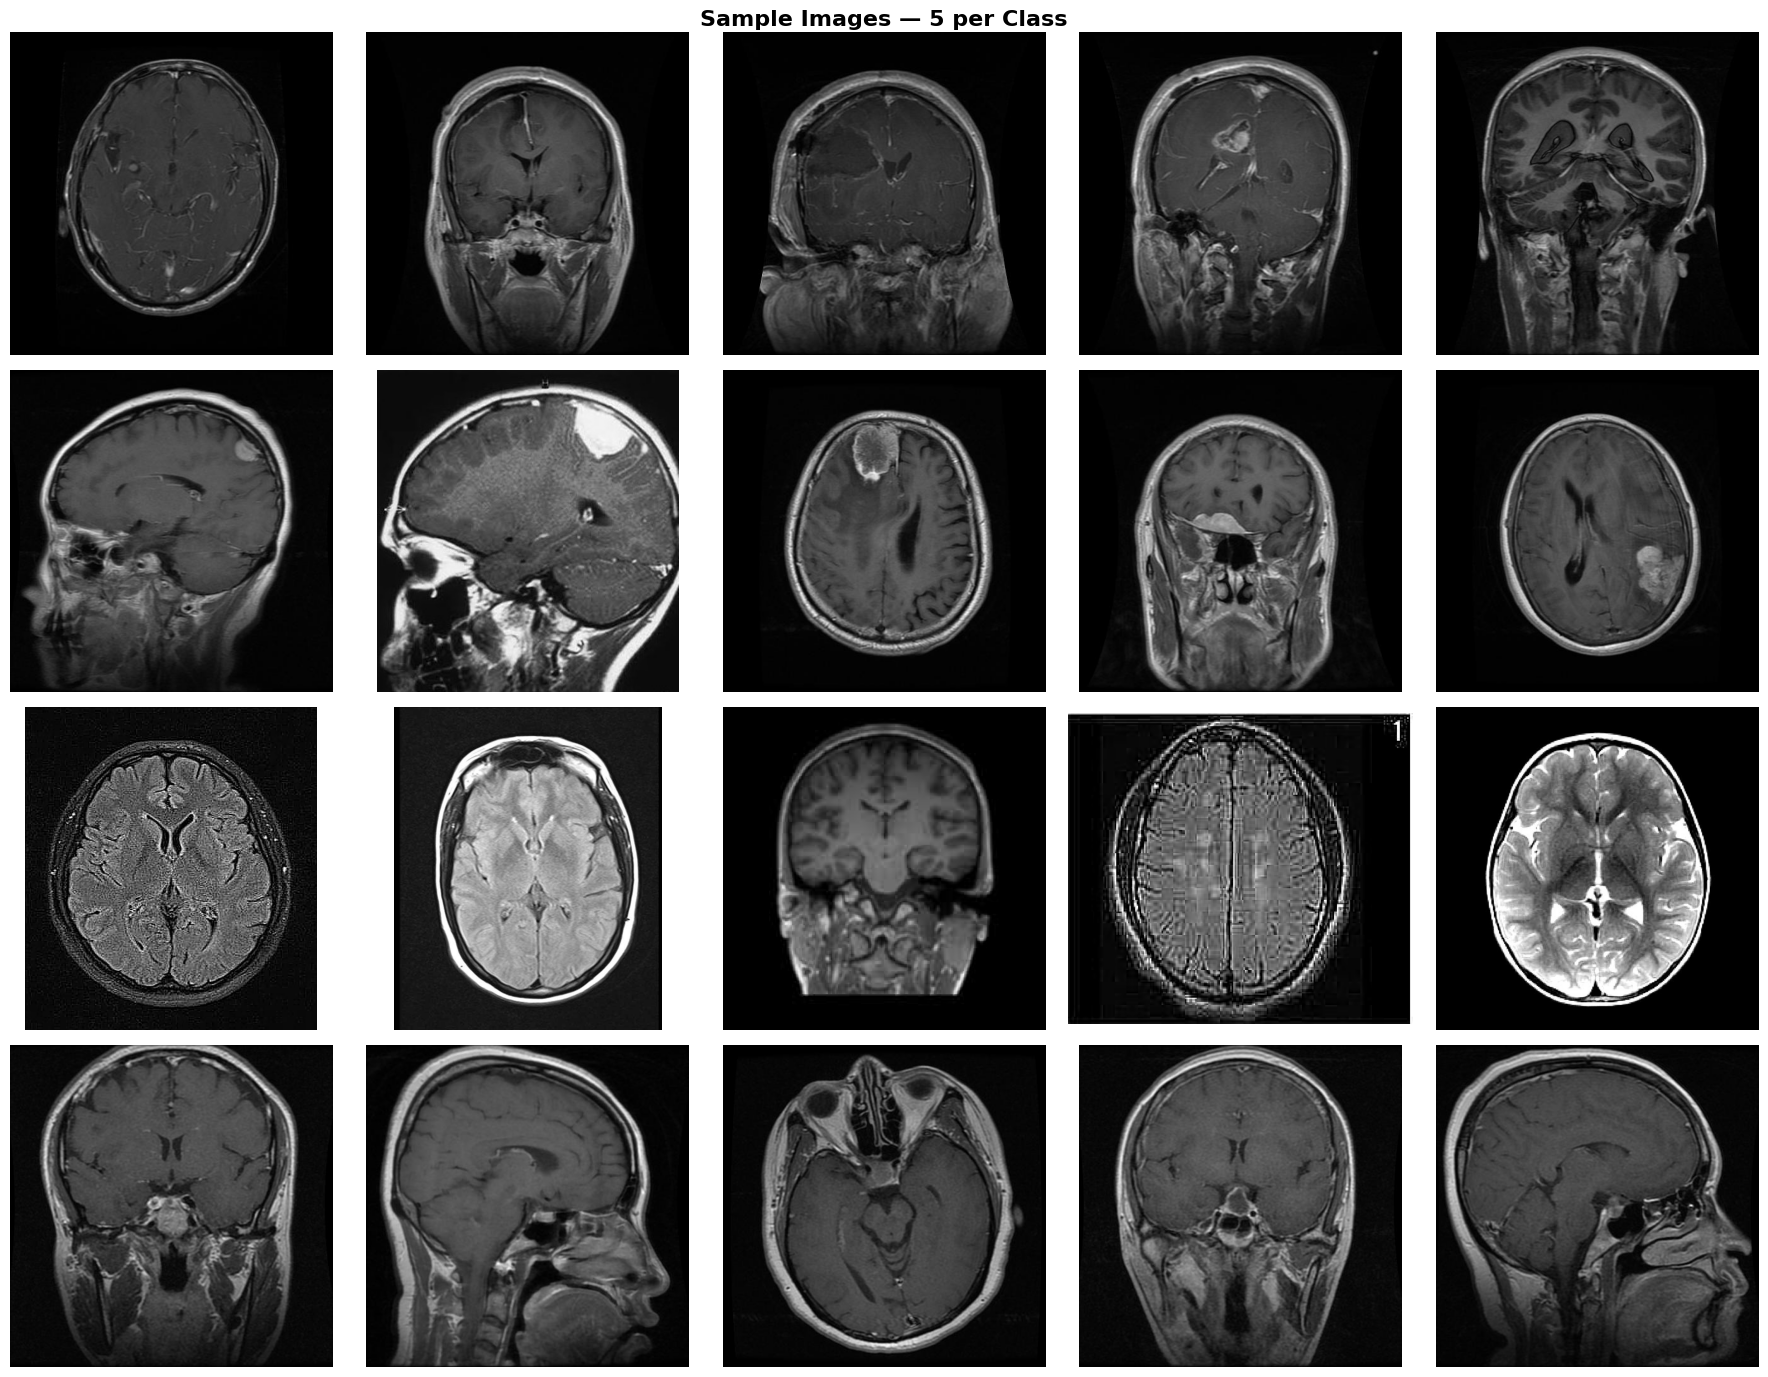

  [✓] Saved: 03_sample_images.png


In [ ]:
# 2.3 Sample Images Per Class 
def load_sample_images(directory, cls, n=5):
    """Load n random sample images from a class folder."""
    folder = directory / cls
    paths  = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
    chosen = random.sample(paths, min(n, len(paths)))
    images = []
    for p in chosen:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    return images

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(18, 14))
fig.suptitle("Sample Images — 5 per Class", fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    samples = load_sample_images(TRAIN_DIR, cls, n=5)
    for col, img in enumerate(samples):
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=13, fontweight='bold',
                                       rotation=90, labelpad=60)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 03_sample_images.png")

### Output Explanation
In this output, I am displaying sample MRI images from each class. This is a manual visual audit step to ensure that images are being read correctly and labels align with their corresponding folders.

By looking across rows, I can also get an intuitive feel for intra-class variability and inter-class overlap. This helps me understand how difficult the classification task might be and whether stronger feature extraction or deeper architecture is justified.


  [EDA] Analyzing image dimensions...


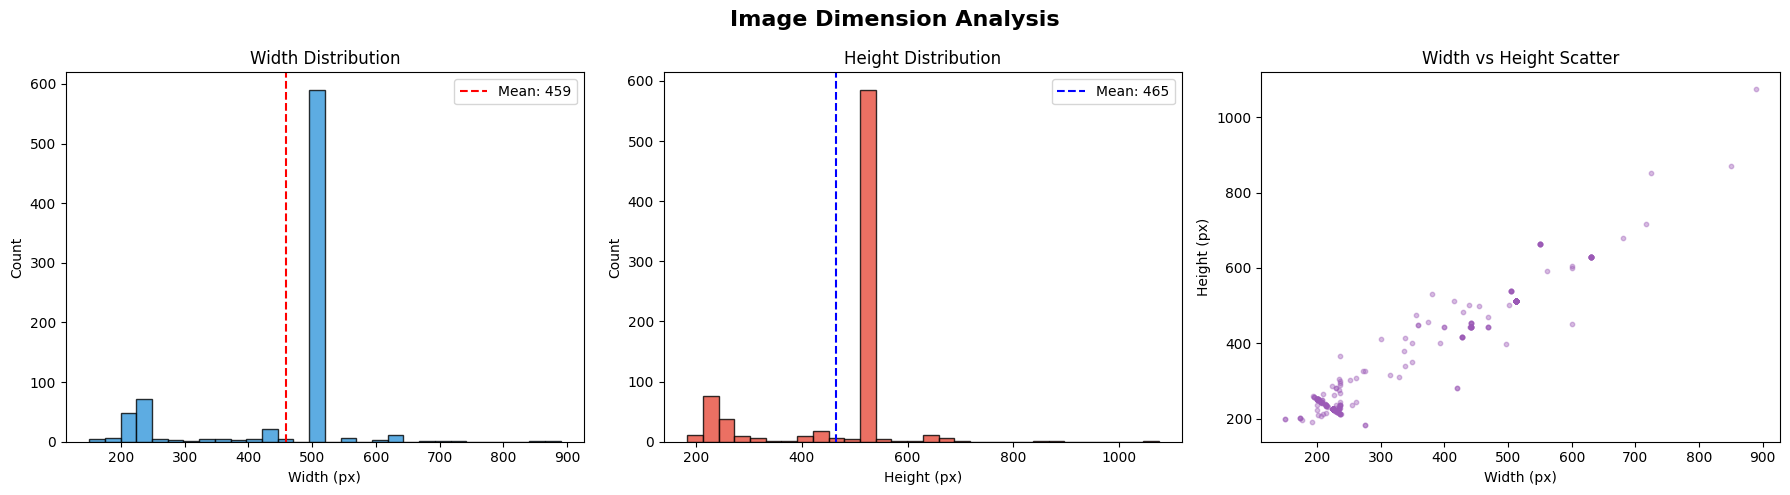

  Avg Width  : 459.3px  |  Std: 116.5px
  Avg Height : 464.7px  |  Std: 112.8px
  [✓] Saved: 04_image_dimensions.png


In [8]:
print("\n  [EDA] Analyzing image dimensions...")

widths, heights = [], []
for cls in CLASS_NAMES:
    cls_path = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    # Sample up to 200 per class for speed
    for p in random.sample(img_paths, min(200, len(img_paths))):
        img = Image.open(p)
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Image Dimension Analysis", fontsize=16, fontweight='bold')

axes[0].hist(widths,  bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.mean(heights), color='blue', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.4, color='#9b59b6', s=10)
axes[2].set_title("Width vs Height Scatter")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_image_dimensions.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Avg Width  : {np.mean(widths):.1f}px  |  Std: {np.std(widths):.1f}px")
print(f"  Avg Height : {np.mean(heights):.1f}px  |  Std: {np.std(heights):.1f}px")
print("  [✓] Saved: 04_image_dimensions.png")

### Output Explanation
This output summarizes the image dimension analysis through width/height histograms and a scatter plot. I use it to understand how much variation exists in raw image sizes before resizing.

The mean and standard deviation values tell me whether a fixed resize to the chosen input resolution is sensible. If variation is too large, resizing can distort anatomy; this check helps confirm my preprocessing choice is practical for stable model training.


  [EDA] Analyzing pixel intensities...


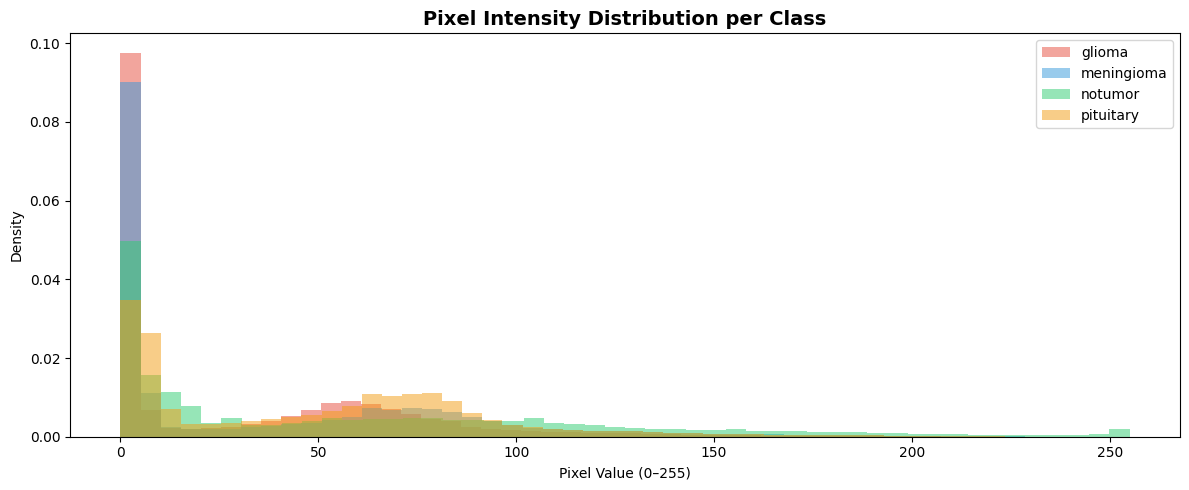

  [✓] Saved: 05_pixel_intensity.png


In [9]:
print("\n  [EDA] Analyzing pixel intensities...")

intensity_data = {cls: [] for cls in CLASS_NAMES}
for cls in CLASS_NAMES:
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(50, len(img_paths)))
    for p in sample:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        intensity_data[cls].extend(img.flatten().tolist())

fig, ax = plt.subplots(figsize=(12, 5))
for cls, color in zip(CLASS_NAMES, colors):
    vals = np.array(intensity_data[cls])
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cls, density=True)
ax.set_title("Pixel Intensity Distribution per Class", fontsize=14, fontweight='bold')
ax.set_xlabel("Pixel Value (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_pixel_intensity.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 05_pixel_intensity.png")

### Output Explanation
This plot describes pixel intensity distributions across classes after grayscale conversion and resizing. I use this to understand whether class separation may also exist in low-level intensity patterns.

If intensity curves overlap heavily, the model will need stronger structural and texture features beyond simple brightness differences. This output gives me a useful intuition about how discriminative raw pixel statistics are before deeper feature learning.

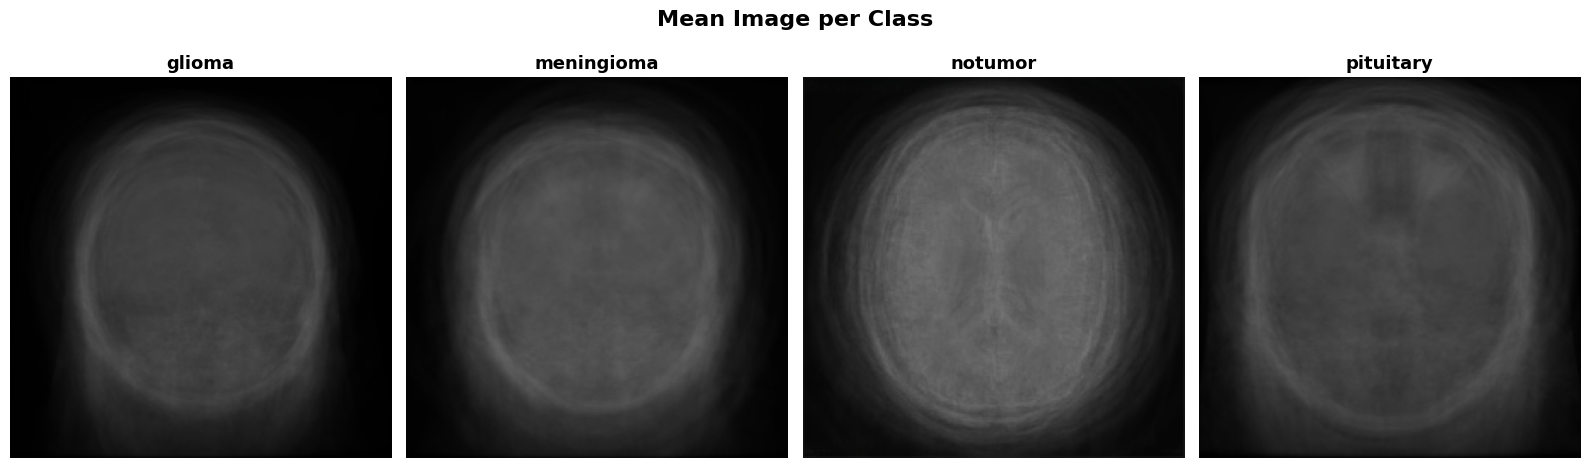

  [✓] Saved: 06_mean_images.png

[✓] EDA Complete!



In [10]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 5))
fig.suptitle("Mean Image per Class", fontsize=16, fontweight='bold')

for ax, cls in zip(axes, CLASS_NAMES):
    cls_path  = TRAIN_DIR / cls
    img_paths = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.png"))
    sample    = random.sample(img_paths, min(100, len(img_paths)))
    stack     = []
    for p in sample:
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        stack.append(img.astype(np.float32))
    mean_img = np.mean(stack, axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_mean_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 06_mean_images.png")

print("\n[✓] EDA Complete!\n")

### Output Explanation
These mean images are generated by averaging multiple samples per class. I use this as a compact visual summary of typical class-wise appearance patterns.

This helps me check whether there are consistent spatial/contrast signatures in each class and whether classes appear visually distinct on average. Even though this is not a predictive result by itself, it gives a strong qualitative signal about expected model separability.

# Loading Datasets (train/val/test)

In [ ]:
import glob
import numpy as np
from sklearn.model_selection import train_test_split

# ── 3.1 Build file-level train/val split  
all_files, all_labels = [], []
for i, cls in enumerate(CLASS_NAMES):
    files = sorted(glob.glob(os.path.join(TRAIN_DIR, cls, "*")))
    all_files.extend(files)
    all_labels.extend([i] * len(files))

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels,
    test_size    = VAL_SPLIT,
    stratify     = all_labels,
    random_state = SEED
)

print(f"  Train: {len(train_files)} | Val: {len(val_files)}")

# 3.2 Image loader 
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def paths_to_dataset(file_paths, labels, batch_size, shuffle=False):
    labels_oh = tf.keras.utils.to_categorical(labels, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels_oh))
    if shuffle:
        ds = ds.shuffle(len(file_paths), seed=SEED, reshuffle_each_iteration=True)
    ds = (ds
          .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds

#  3.3 Build datasets 
train_ds_full = paths_to_dataset(train_files, train_labels, BATCH_SIZE, shuffle=True)
val_ds        = paths_to_dataset(val_files,   val_labels,   BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels      = 'inferred',
    label_mode  = 'categorical',
    class_names = CLASS_NAMES,
    image_size  = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

  Train: 4480 | Val: 1120
Found 1600 files belonging to 4 classes.


### Output Explanation
In this output, I am verifying the file-level stratified split between training and validation sets. The printed sample counts confirm that my split pipeline is active and producing expected dataset sizes.

This is critical because a clean split directly affects the reliability of validation performance. I use this checkpoint to ensure there is no accidental leakage and that class proportions are preserved when moving from raw files to TensorFlow datasets.

# Normalization layers and Data Augumentations

In [12]:
import os
print(os.listdir(TRAIN_DIR))  # what does this show?
# and how many images per class?
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls}: {count} images")

['pituitary', 'notumor', 'meningioma', 'glioma']
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


### Output Explanation
This output shows the class folder names and image counts per class directly from disk. I use it as a quick filesystem-level verification before finalizing preprocessing.

It helps confirm that directory naming matches my `CLASS_NAMES` definition and that there are no missing folders. This small check prevents subtle bugs where wrong folder mapping can silently corrupt label assignments.

In [13]:
import os
sample_files = os.listdir(os.path.join(TRAIN_DIR, 'glioma'))[:10]
for f in sample_files:
    print(f)

Tr-gl_1362.jpg
Tr-gl_821.jpg
Tr-gl_825.jpg
Tr-gl_315.jpg
Tr-gl_52.jpg
Tr-gl_626.jpg
Tr-gl_827.jpg
Tr-gl_1033.jpg
Tr-gl_1096.jpg
Tr-gl_1290.jpg


### Output Explanation
Here, I am printing a few sample filenames from one class to inspect naming consistency and file format patterns. This is a lightweight debugging step that helps me catch unusual filenames or hidden artifacts early.

By checking actual file names, I can confirm that file discovery logic is reading valid inputs and not accidentally including non-image or malformed files.

In [ ]:
# Preprocessing   
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = normalization_layer(images)
    images = data_augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization_layer(images)
    return images, labels

# Build final datasets  
train_ds = (train_ds_full
            .cache()
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds = (val_ds
          .cache()
          .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

test_ds = (test_ds
           .cache()
           .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
           .prefetch(AUTOTUNE))

In [24]:
sample_batch_raw, sample_labels = next(iter(
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASS_NAMES,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=4,
        shuffle=True,
        seed=SEED
    )
))


Found 5600 files belonging to 4 classes.


### Output Explanation
This output is a quick validation that I can successfully fetch a mini-batch from the training pipeline. It confirms that the dataset loader, class mapping, batching, and image resizing steps are all functioning together.

I treat this as a pipeline health check before deeper augmentation and model training. If this step works cleanly, I know the downstream preprocessing stages are less likely to fail unexpectedly.

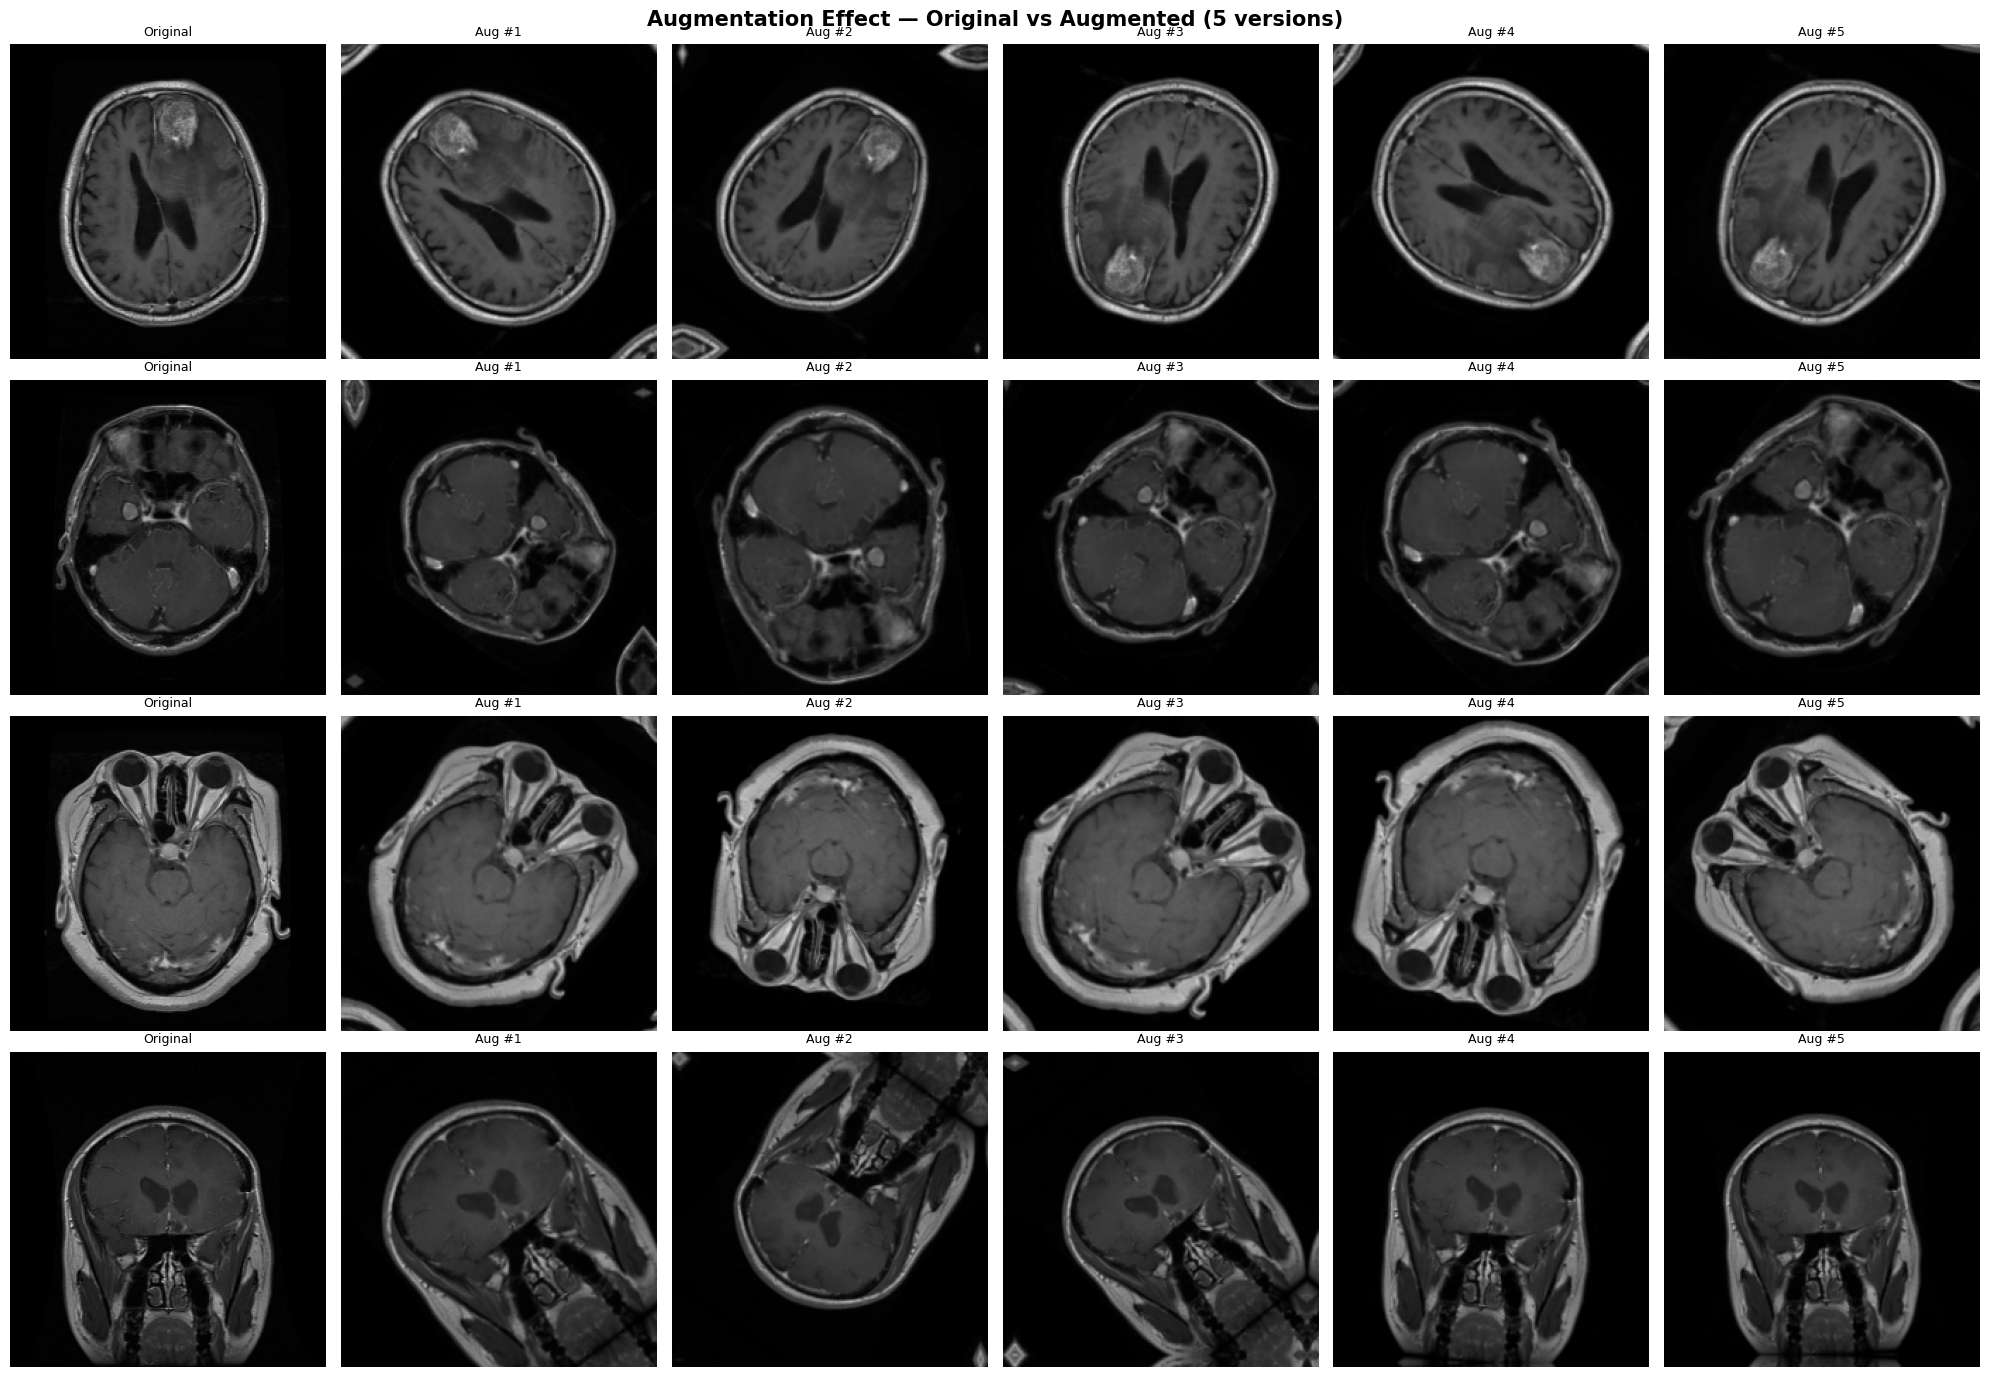

  [✓] Saved: 07_augmentation_preview.png


In [25]:
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
fig.suptitle("Augmentation Effect — Original vs Augmented (5 versions)",
             fontsize=15, fontweight='bold')

aug_pipeline = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

for row in range(4):
    img      = sample_batch_raw[row]
    label_id = tf.argmax(sample_labels[row]).numpy()
    cls_name = CLASS_NAMES[label_id]

    # Original
    axes[row, 0].imshow(img.numpy().astype(np.uint8))
    axes[row, 0].set_title("Original", fontsize=9)
    axes[row, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')
    axes[row, 0].axis('off')

    # 5 augmented versions
    for col in range(1, 6):
        aug_img = aug_pipeline(tf.expand_dims(img, 0), training=True)[0]
        axes[row, col].imshow(aug_img.numpy().astype(np.uint8))
        axes[row, col].set_title(f"Aug #{col}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_augmentation_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("  [✓] Saved: 07_augmentation_preview.png")

### Output Explanation
This figure compares original images with multiple augmented versions. I use it to verify that augmentation is diverse enough to improve generalization while still preserving medically meaningful visual content.

The transformed samples show me whether operations like rotation, zoom, contrast, and flipping are realistic for this task. If augmentations look too aggressive or unnatural, I would dial them back to avoid teaching the model misleading patterns.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Deeper CNN model

In [27]:
def conv_block(x, filters, block_name, dropout_rate=0.25):
    # First conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv1",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu1")(x)
    # Second conv
    x = layers.Conv2D(
        filters, (3, 3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv2",
        use_bias=False
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.Activation('relu', name=f"{block_name}_relu2")(x)
    # Downsample
    x = layers.MaxPooling2D((2, 2), name=f"{block_name}_pool")(x)
    x = layers.SpatialDropout2D(dropout_rate, name=f"{block_name}_sdrop")(x)
    return x


def build_cnn_v3(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape, name="input")

    x = conv_block(inputs, filters=32,  block_name="block1", dropout_rate=0.10)
    # Output: (112, 112, 32)
    x = conv_block(x,      filters=64,  block_name="block2", dropout_rate=0.15)
    # Output: (56, 56, 64)
    x = conv_block(x,      filters=128, block_name="block3", dropout_rate=0.20)
    # Output: (28, 28, 128)
    x = conv_block(x,      filters=256, block_name="block4", dropout_rate=0.20)
    # Output: (14, 14, 256)
    x = conv_block(x,      filters=512, block_name="block5", dropout_rate=0.25)
    # Output: (7, 7, 512)

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.Dense(512, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense1")(x)
    x = layers.BatchNormalization(name="dense1_bn")(x)
    x = layers.Activation('relu', name="dense1_relu")(x)
    x = layers.Dropout(0.40, name="dense1_drop")(x)

    x = layers.Dense(256, use_bias=False, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(1e-4), name="dense2")(x)
    x = layers.BatchNormalization(name="dense2_bn")(x)
    x = layers.Activation('relu', name="dense2_relu")(x)
    x = layers.Dropout(0.30, name="dense2_drop")(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="BrainTumorCNN_v3")
    return model

In [28]:
model = build_cnn_v3()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Penalize glioma and meningioma misses harder
class_weights = {
    0: 1.5,   # glioma      — was 0.59 recall
    1: 1.5,   # meningioma  — was 0.59 recall
    2: 0.7,   # notumor     — was over-predicted
    3: 1.0    # pituitary   — already strong
}

In [30]:
model.summary()

Model: "BrainTumorCNN_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_sdrop (SpatialDropout2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_sdrop (SpatialDropout2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_sdrop (SpatialDropout2D) │ (None, 28, 28, 128)    │             

 Total params: 5,115,492 (19.51 MB)

 Trainable params: 5,109,988 (19.49 MB)

 Non-trainable params: 5,504 (21.50 KB)

### Output Explanation
The model summary output helps me inspect architecture depth, layer sequence, and parameter count. I use this to confirm that the intended deeper CNN design has been built correctly and that tensor shape transitions look valid.

I also read this summary to estimate training cost and potential overfitting risk. A high parameter count can improve representation power, but it also requires careful regularization and monitoring on validation data.

In [29]:
try:
    tf.keras.utils.plot_model(
        model,
        to_file=str(OUTPUT_DIR / "08_model_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=80
    )
    print("  [✓] Saved: 08_model_architecture.png")
except Exception:
    print("  [!] Model plot requires pydot/graphviz — skipping")

  [✓] Saved: 08_model_architecture.png


### Output Explanation
This output tells me whether the model architecture diagram was successfully exported. If the image is saved, I can include it in documentation to clearly communicate network design.

If graph dependencies are missing, the fallback message is still useful because it keeps the notebook execution robust without interrupting the full training workflow.

In [ ]:
rm -rf /kaggle/working/outputs

In [ ]:
print("\n[TRAIN] Compiling and training...\n")

# Resume support for multi-day training 
LATEST_CHECKPOINT = CHECKPOINT_DIR / "latest.keras"
BEST_CHECKPOINT   = OUTPUT_DIR / "best_model.keras"
TRAIN_LOG         = OUTPUT_DIR / "training_log.csv"
initial_epoch     = 0

if LATEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading latest checkpoint: {LATEST_CHECKPOINT}")
    model = keras.models.load_model(str(LATEST_CHECKPOINT))
    if TRAIN_LOG.exists():
        try:
            initial_epoch = len(pd.read_csv(TRAIN_LOG))
        except Exception:
            initial_epoch = 0
elif BEST_CHECKPOINT.exists():
    print(f"  [RESUME] Loading best checkpoint: {BEST_CHECKPOINT}")
    model = keras.models.load_model(str(BEST_CHECKPOINT))
    print("  [RESUME] Best checkpoint loaded without epoch state; training will restart from epoch 1")
else:
    model = build_cnn_v3()

# Loss 
# Switched from focal loss to label smoothing — more stable with this LR
# Focal loss reintroducible later once training curve is smooth
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

if not getattr(model, 'optimizer', None):
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=3e-4),
        loss      = loss_fn,
        metrics   = [
            'accuracy',
            keras.metrics.AUC(name='auc', multi_label=False),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

# LR Warmup 
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return 3e-4 * ((epoch + 1) / 5)  # ramp up over first 5 epochs
    return lr

# Callbacks 
callbacks = [
    keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1),
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = str(BEST_CHECKPOINT),
        monitor        = 'val_loss',   # consistent with EarlyStopping
        save_best_only = True,
        verbose        = 1
    ),
    ModelCheckpoint(
        filepath       = str(LATEST_CHECKPOINT),
        save_best_only = False,
        save_freq      = 'epoch',
        verbose        = 0
    ),
    keras.callbacks.CSVLogger(str(TRAIN_LOG), append=True),
    keras.callbacks.BackupAndRestore(backup_dir=str(CHECKPOINT_DIR / 'backup_state')),
    TensorBoard(
        log_dir        = str(OUTPUT_DIR / "logs"),
        histogram_freq = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,     # tightened from 5 to act faster
        min_lr   = 1e-7,
        verbose  = 1
    ),
]

# Train 
print("\n[TRAIN] Starting training...\n")
train_start = time.time()

history = model.fit(
    train_ds,
    initial_epoch   = initial_epoch,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

train_end  = time.time()
elapsed    = train_end - train_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)

print("\n  [✓] Training complete!")


[TRAIN] Compiling and training...


[TRAIN] Starting training...


Epoch 1: LearningRateScheduler setting learning rate to 5.9999999999999995e-05.
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.3824 - auc: 0.6496 - loss: 2.0248 - precision: 0.4690 - recall: 0.2371
Epoch 1: val_loss improved from inf to 2.32586, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 48s 224ms/step - accuracy: 0.3828 - auc: 0.6499 - loss: 2.0242 - precision: 0.4694 - recall: 0.2374 - val_accuracy: 0.2500 - val_auc: 0.5697 - val_loss: 2.3259 - val_precision: 0.2576 - val_recall: 0.2500 - learning_rate: 6.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 0.00011999999999999999.
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5188 - auc: 0.7695 - loss: 1.7946 - precision: 0.6115 - recall: 0.3386
Epoch 2: val_loss improved from 2.32586 to 2.24478, saving model to /kaggle/working/outputs/best_model.keras
140/140 ━━━━━━━━━

### Output Explanation
This is the main training log, and I treat it as the core performance timeline of the experiment. It shows checkpoint loading behavior, epoch-by-epoch progress, callback actions, and final completion status.

From this output, I can track convergence behavior, identify instability, and verify that resume training support is working correctly. Messages from early stopping and learning-rate adjustments are especially valuable because they explain *why* training dynamics changed over time.

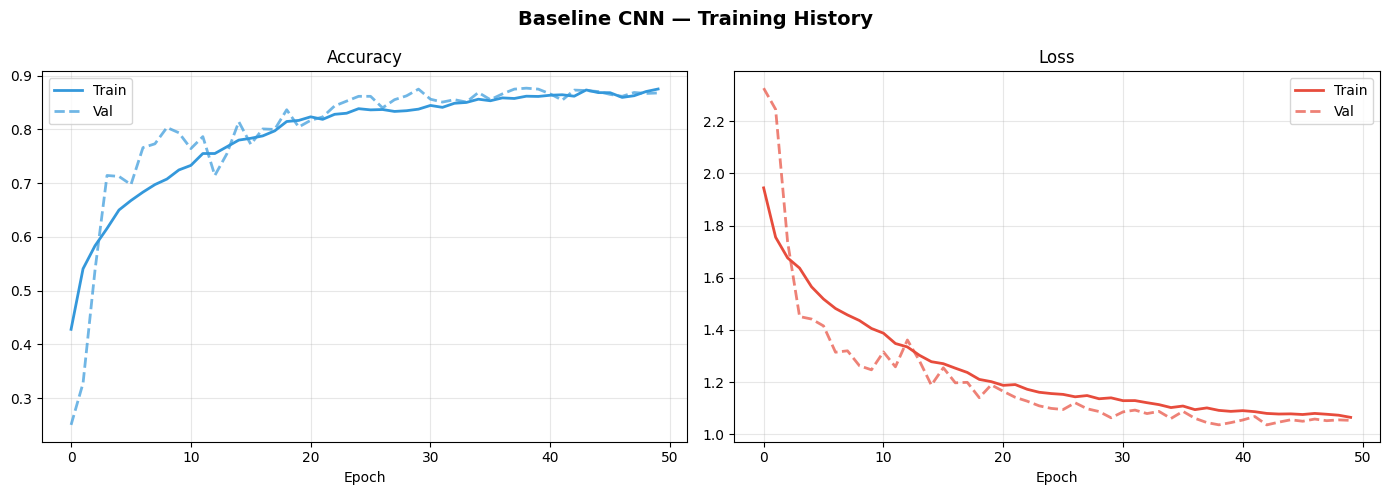

In [36]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Training History", fontsize=14, fontweight='bold')
 
for ax, (m, title, c) in zip(axes, [('accuracy','Accuracy','#3498db'), ('loss','Loss','#e74c3c')]):
    ax.plot(history.history[m],          label='Train', color=c, linewidth=2)
    ax.plot(history.history[f'val_{m}'], label='Val',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Output Explanation
These baseline training curves give me a compact view of how train and validation metrics evolve across epochs. I use this to visually diagnose underfitting, overfitting, and optimization stability.

When train and validation trends move together smoothly, it indicates healthier generalization. If a large gap appears, I interpret it as overfitting and consider stronger regularization, augmentation, or earlier stopping.

In [ ]:
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.concatenate([np.argmax(labels.numpy(), axis=1)
                                for _, labels in test_ds])

#  7.3 Classification Report 
print("\n  Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step

  Classification Report:
              precision    recall  f1-score   support

      glioma       0.79      0.72      0.76       400
  meningioma       0.86      0.56      0.68       400
     notumor       0.78      0.97      0.87       400
   pituitary       0.82      0.97      0.89       400

    accuracy                           0.81      1600
   macro avg       0.81      0.81      0.80      1600
weighted avg       0.81      0.81      0.80      1600



### Output Explanation
This output includes predicted probabilities, predicted classes, and the final classification report. I use it as my class-wise performance checkpoint rather than relying only on overall accuracy.

I focus especially on precision, recall, and F1 for each tumor type. In medical imaging, recall is often critical because missing a positive case can be more harmful than a false alarm, so this report helps me evaluate model usefulness from a practical perspective.

In [38]:
print("\n[PLOT] Generating training curves...\n")

def plot_training_history(history):
    metrics = ['accuracy', 'loss', 'auc', 'precision', 'recall']
    titles  = ['Accuracy', 'Loss', 'AUC', 'Precision', 'Recall']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training History", fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        if metric in history.history:
            axes[i].plot(history.history[metric],       label='Train', color='#3498db', linewidth=2)
            axes[i].plot(history.history[f'val_{metric}'], label='Val',   color='#e74c3c', linewidth=2)
            axes[i].set_title(title, fontsize=13, fontweight='bold')
            axes[i].set_xlabel("Epoch")
            axes[i].set_ylabel(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch = np.argmax(history.history['val_accuracy'])
    best_val   = max(history.history['val_accuracy'])
    axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch+1})')
    axes[0].legend()

    axes[-1].axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "09_training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Best Val Accuracy : {best_val:.4f}  (epoch {best_epoch+1})")
    print("  [✓] Saved: 09_training_curves.png")


[PLOT] Generating training curves...



### Output Explanation
This message indicates I am preparing a comprehensive training history visualization function. It sets up a multi-metric view so I can inspect not only accuracy/loss but also AUC, precision, and recall together.

I prefer this richer view because it provides better diagnostic depth. A model can look good on one metric while degrading on another, so this setup helps me make more balanced conclusions.

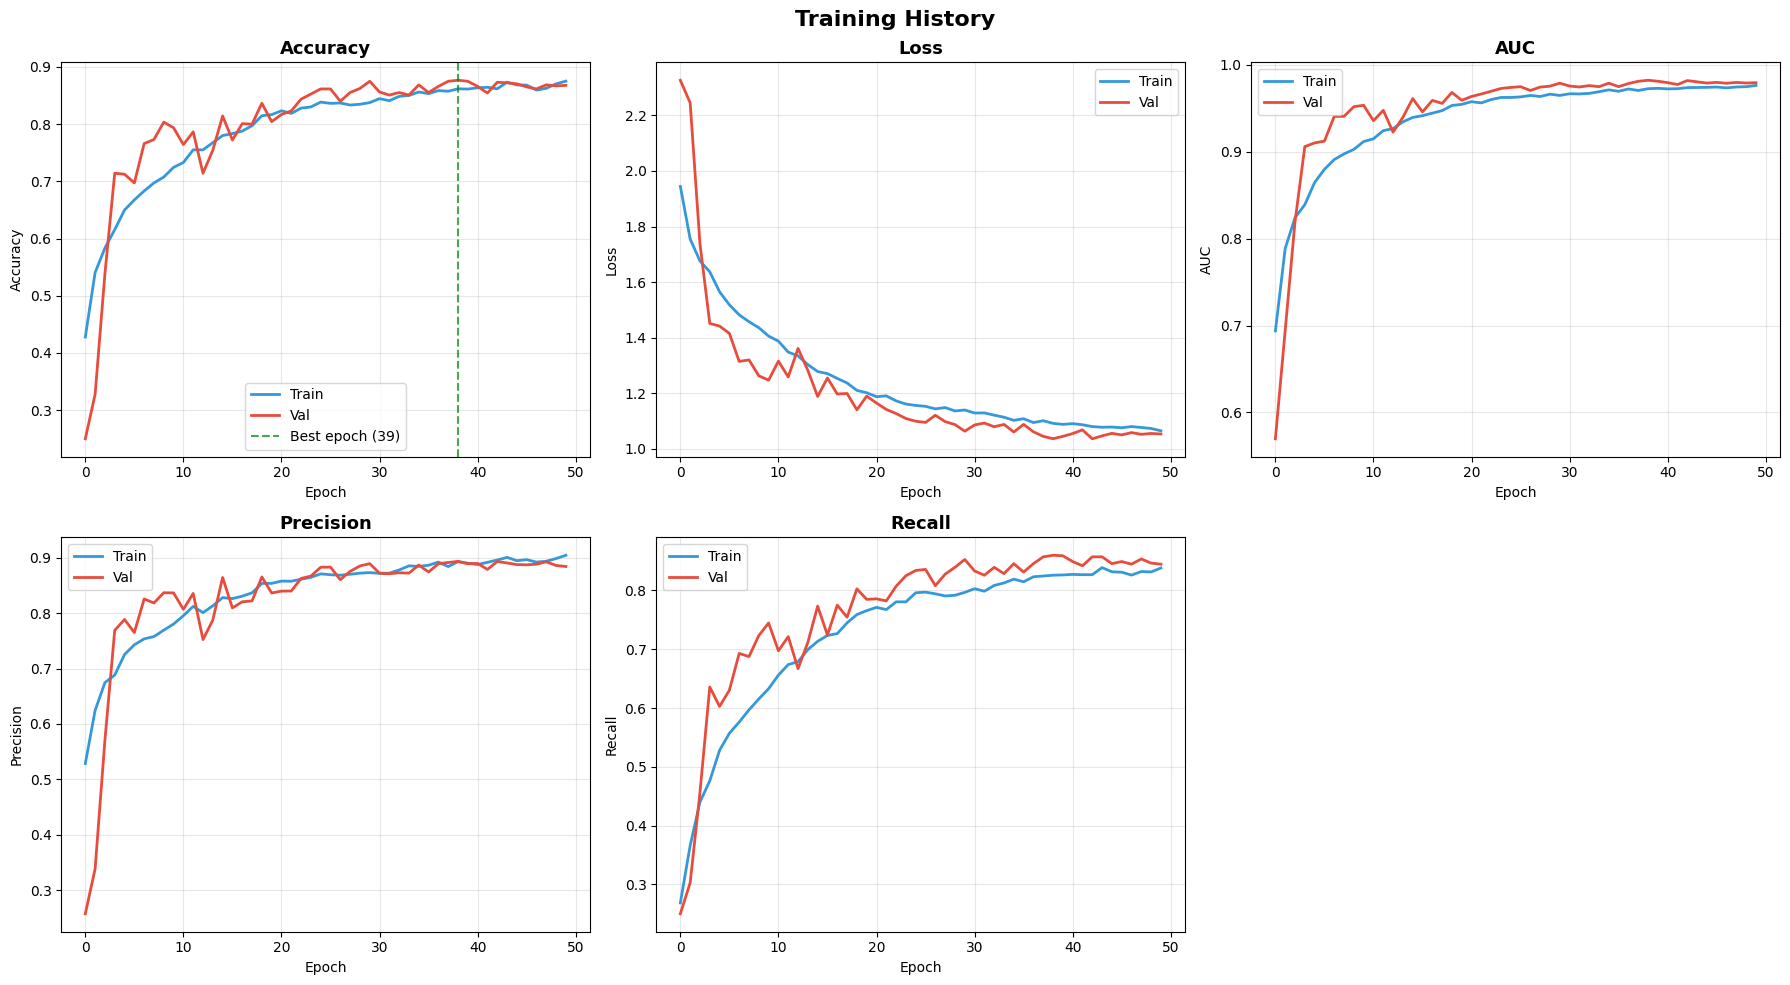

  Best Val Accuracy : 0.8768  (epoch 39)
  [✓] Saved: 09_training_curves.png


In [39]:
plot_training_history(history)

### Output Explanation
This final plot summarizes the full training dynamics and highlights the best validation epoch. I use it as an experiment-level snapshot to decide whether the model is ready or needs another tuning cycle.

The best validation marker helps me justify model selection objectively, while the metric trajectories tell me where to improve next (learning rate schedule, regularization strength, or class balancing strategy).